# Protein Sequence Tokenization Stretegy Comparative Analysis

This notebook implements the phase-2 Tokenization of animo acids and compare strategies based on Vocab size and

<strong>_out of scope:_</strong>

- compare strategies based on Generative and Classification tasks


In [1]:
import os
import sys
import gc
import json
import time
import traceback
import resource
from pathlib import Path

from collections import Counter
from itertools import chain

import math

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq

from IPython.display import display
from tqdm.auto import tqdm

from util.file_utils import ensure_directories, iter_dataset
from util.text_similarity import rank_texts
from util.seq_util import inspect_residue_distribution
from tokenizer_module import create_tokenizer

In [2]:
REPO_ROOT = Path.cwd().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_PATH = REPO_ROOT / "data/interim/protein_eda/protein_corpus.parquet"
OUTPUT_DIR = REPO_ROOT / "data/interim/protein_tokenization"
FIGURE_OUTPUT_DIR = REPO_ROOT / "results/protein_tokenization/figures"
ARTIFACT_OUTPUT_DIR = REPO_ROOT / "results/protein_tokenization/artifacts"

MAX_SEQ_LENGTH = 512
PARSE_BATCH_SIZE = 2**16
# TOKENIZATION_STRATEGIES = ["Unigram", "BPE", "WordPiece", "words", "pairs", "k-mers"]
TOKENIZATION_STRATEGIES = ["BPE"]
MIN_FREQUENCIES = [3]
KMER_SIZES = [3, 5, 6, 7, 9]
VOCAB_SIZES = [256]
RARE_RESIDUE_POLICY = "keep"  #  None replace_with_unk replace_with_nn
SAMPLE_MODE = None  # None  #500

SAVE_ARTIFACTS = True
SAVE_FIGURES = True

TOKENIZER_CONFIGS = (
    [{"name": "words", "requires_training": False}]
    + [{"name": "Unigram", "requires_training": True, "vocab_size": vs} for vs in VOCAB_SIZES]
    + [{"name": "BPE", "requires_training": True, "vocab_size": vs, "min_frequency": mf} for vs in VOCAB_SIZES for mf in MIN_FREQUENCIES]
    + [{"name": "WordPiece", "requires_training": True, "vocab_size": vs} for vs in VOCAB_SIZES]
    + [{"name": "pairs", "requires_training": False, "pair_mode": "sliding"}]
    + [{"name": "k-mers", "requires_training": False, "k": k, "mode": "sliding"} for k in KMER_SIZES]
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
ensure_directories(ARTIFACT_OUTPUT_DIR, FIGURE_OUTPUT_DIR, OUTPUT_DIR)


def debug_log(stage, **details):
    rss_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024
    timestamp = time.strftime("%H:%M:%S")
    detail_str = ", ".join(f"{key}={value}" for key, value in details.items())
    prefix = f"[{timestamp}] {stage} | rss_max_mb={rss_mb:,.1f}"
    print(f"{prefix} | {detail_str}" if detail_str else prefix, flush=True)


last_successful_tokenizer_dir = None
last_successful_tokenizer_name = None

## Parse Corpus

Parse every available `protein.faa` file, preserve provenance, and surface malformed records or headers.


In [3]:
protein_dataset = ds.dataset(str(DATA_PATH), format="parquet")

dataset_schema = pd.DataFrame(
    {
        "column": protein_dataset.schema.names,
        "dtype": [str(t) for t in protein_dataset.schema.types],
    }
)
records_total_count = protein_dataset.count_rows()
print(f"Records: {records_total_count:,}")

Records: 88,497,376


In [4]:
if SAMPLE_MODE is not None:
    print(f"Taking a sample of {SAMPLE_MODE} records")
    protein_dataset = ds.dataset(protein_dataset.head(SAMPLE_MODE))
    records_total_count = protein_dataset.count_rows()


display(dataset_schema)

,column,dtype
0,assembly_id,string
1,sequence_id,string
2,ambiguous_residues,string
3,functional_annotations,string
4,raw_header,string
5,sequence_length,int64
6,sequence,string


In [5]:
TOTAL_RECORDS = records_total_count
TOTAL_BATCHES = math.ceil(TOTAL_RECORDS / PARSE_BATCH_SIZE)
print(f"Total batches (batch size {PARSE_BATCH_SIZE}): {TOTAL_BATCHES:,}")

Total batches (batch size 65536): 1,351


In [6]:
# find all unique functional_annotations and count their occurrences
annotation_counts = Counter()

for batch in iter_dataset(protein_dataset, batch_size=PARSE_BATCH_SIZE, desc="Counting annotations"):
    df_batch = batch.to_pandas()
    annotation_counts.update(df_batch["functional_annotations"].explode())

annotation_counts_df = pd.DataFrame(annotation_counts.items(), columns=["annotation", "count"]).sort_values(by="count", ascending=False)
del annotation_counts
del df_batch
del batch
gc.collect()


Counting annotations:   0%|          | 0.00/88.5M [00:00<?, ?rows/s]

67

In [7]:
if SAVE_ARTIFACTS:
    annotation_counts_df.to_csv(ARTIFACT_OUTPUT_DIR / "annotation_counts.csv", index=False)

print(f"Number of Annotations: {annotation_counts_df.shape[0]:_}")
display(annotation_counts_df.sort_values(by="annotation", ascending=True).head(10))

Number of Annotations: 123_396


,annotation,count
980,,19891
123303,"(+)-(1(10)E,4E,6S,7R)-germacradien-6-ol synthase",1
48904,(+)-T-muurolol synthase,1
95350,(+)-kolavelool synthase,2
88730,(-)-alpha-amorphene synthase,82
83993,(-)-beta-caryophyllene synthase,1
108247,(-)-delta-cadinene synthase,5
56324,(-)-gamma-cadinene synthase,9
121043,"(12E)-labda-8(17),12,14-triene synthase",1
17142,"(2,3-dihydroxybenzoyl)adenylate synthase",3314


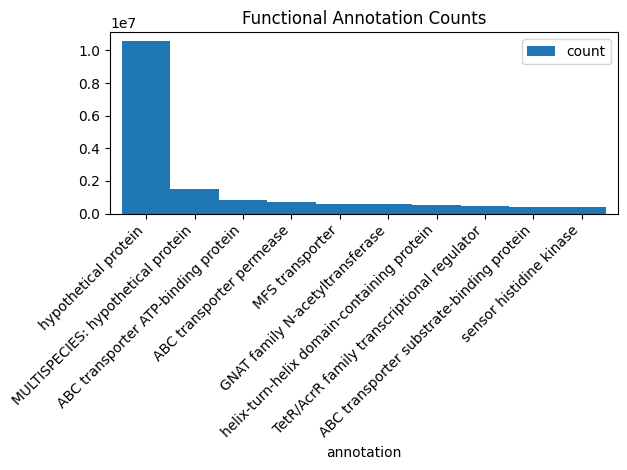

In [8]:
annotation_counts_df.head(10).plot(kind="bar", x="annotation", y="count", title="Functional Annotation Counts", width=1.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

### Annotation Similarity Search

Use the reusable text ranking utility to search functional annotations with either fuzzy matching or semantic similarity.


In [9]:
semantic_annotation_matches = rank_texts(annotation_counts_df["annotation"], "anti microbial", method="semantic", threshold=0.25)
del annotation_counts_df
gc.collect()

display(semantic_annotation_matches.top_k(40))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/483 [00:00<?, ?it/s]

0                       microbial anti-inflammatory protein
1                                      bacteriocin microcin
2                                               bacteriocin
3                                anti-bacteriophage protein
4                                                  microcin
5                                    antibiotic transporter
6                                antibiotic ABC transporter
7                         putative bacteriocin-like product
8                                            bacterioferrin
9                      putative antibiotic immunity protein
10                                antimicrobial peptide LCI
11                                      bacteriohemerythrin
12                                              rhizobiocin
13                            antibiotic resistance protein
14                            antibiotic-resistance protein
15                                         bacteriocin BlpI
16                 MULTISPECIES: antibio

In [10]:
if SAVE_ARTIFACTS:
    semantic_annotation_matches.top_k(40).reset_index(drop=True).to_csv(ARTIFACT_OUTPUT_DIR / "semantic_annotation_matches.csv", index=False)

del semantic_annotation_matches
gc.collect()

0

#### MLM vs next-token prediction

MLM

- sees left + right context

- good for representation learning

Causal LM

- only sees left context

- better for generation

For proteins, MLM is often a very strong choice unless you specifically want sequence generation.


In [11]:
STANDARD_RESIDUES = set("ACDEFGHIKLMNPQRSTVWY")
RARE_RESIDUES = set("XBZJUO")  # misstyped tokens that appear in the dataset
VALID_RESIDUES = STANDARD_RESIDUES | RARE_RESIDUES

SPECIAL_TOKENS = [
    "[PAD]",  # padding
    "[UNK]",  # unknown token for out-of-vocabulary residues
    "[CLS]",  # start of sequence (classification token)
    "[SEP]",  # separator token (not used in single sequence tasks but reserved for potential future use)
    "[MASK]",  # mask token for masked language modeling
    "[UNKAA]",  # optional custom placeholder token for rare residues (if using replace_with_unk policy)
]

check correct resudue and distribution


In [12]:
AA = np.frombuffer(b"ACDEFGHIKLMNPQRSTVWYXBZUOJ", dtype=np.uint8)
aa_set = set(AA.tolist())
residue_totals = np.zeros(256, dtype=np.int64)

for batch in iter_dataset(protein_dataset, batch_size=PARSE_BATCH_SIZE, desc="Counting residues"):
    seqs = batch.column("sequence").to_pylist()
    blob = "".join(seqs).encode("ascii", errors="ignore")
    arr = np.frombuffer(blob, dtype=np.uint8)
    residue_totals += np.bincount(arr, minlength=256)

rows = [(chr(i), int(residue_totals[i])) for i in sorted(aa_set) if residue_totals[i] > 0]
residue_counts = Counter(dict(rows))
df = pd.DataFrame(residue_counts.items(), columns=["residue", "count"]).sort_values("residue").reset_index(drop=True)
display(df)

Counting residues:   0%|          | 0.00/88.5M [00:00<?, ?rows/s]

,residue,count
0,A,3103905263
1,B,236
2,C,246133848
3,D,1632415528
4,E,1726825396
5,F,1076972394
6,G,2316024175
7,H,603663444
8,I,1555618824
9,J,110


In [13]:
if SAVE_ARTIFACTS:
    df.to_csv(ARTIFACT_OUTPUT_DIR / "residue_counts.csv", index=False)

del residue_counts
del df
del batch
gc.collect()

21